In [3]:
# Setup: Load NBA season stats dataset and connect to SQLite database
import pandas as pd
import sqlite3

# Load the CSV
df = pd.read_csv('../data/Seasons_Stats.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (24691, 53)

Columns: ['Unnamed: 0', 'Year', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'blanl', 'OWS', 'DWS', 'WS', 'WS/48', 'blank2', 'OBPM', 'DBPM', 'BPM', 'VORP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']

First 5 rows:


,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


In [4]:
# Data Cleaning: Filter to modern era (1980+), remove incomplete records,
# and calculate per-game stats (PPG, APG, RPG) from season totals

# Drop the junk index column
df = df.drop(columns=['Unnamed: 0'])

# Filter to modern era (1980+) where stats are complete
df_modern = df[df['Year'] >= 1980].copy()

# Drop rows where Player or PTS is missing
df_modern = df_modern.dropna(subset=['Player', 'PTS', 'G'])

# Calculate points per game and assists per game
df_modern['PPG'] = (df_modern['PTS'] / df_modern['G']).round(2)
df_modern['APG'] = (df_modern['AST'] / df_modern['G']).round(2)
df_modern['RPG'] = (df_modern['TRB'] / df_modern['G']).round(2)

# Load into SQLite database
conn = sqlite3.connect('../data/nba.db')
df_modern.to_sql('stats', conn, if_exists='replace', index=False)

print("Rows loaded into database:", pd.read_sql("SELECT COUNT(*) as count FROM stats", conn)['count'][0])

Rows loaded into database: 18927


In [3]:
# Question 1: Which players had the highest scoring seasons in NBA history?
# Filter to players with 50+ games to remove small sample flukes

query1 = """
SELECT 
    Player,
    Tm,
    Year,
    ROUND(PPG, 2) as points_per_game,
    ROUND(FG, 1) as field_goals_made,
    ROUND("FG%", 3) as fg_percentage,
    G as games_played
FROM stats
WHERE G >= 50
    AND PPG >= 20
ORDER BY PPG DESC
LIMIT 20
"""

top_scorers = pd.read_sql(query1, conn)
print(top_scorers)

               Player   Tm    Year  points_per_game  field_goals_made  \
0     Michael Jordan*  CHI  1987.0            37.09            1098.0   
1         Kobe Bryant  LAL  2006.0            35.40             978.0   
2     Michael Jordan*  CHI  1988.0            34.98            1069.0   
3     Michael Jordan*  CHI  1990.0            33.57            1034.0   
4      George Gervin*  SAS  1980.0            33.14            1024.0   
5      Allen Iverson*  PHI  2006.0            33.01             815.0   
6       Bernard King*  NYK  1985.0            32.89             691.0   
7     Michael Jordan*  CHI  1993.0            32.58             992.0   
8     Michael Jordan*  CHI  1989.0            32.51             966.0   
9      George Gervin*  SAS  1982.0            32.29             993.0   
10      Tracy McGrady  ORL  2003.0            32.09             829.0   
11       Kevin Durant  OKC  2014.0            32.01             849.0   
12  Russell Westbrook  OKC  2017.0            31.58

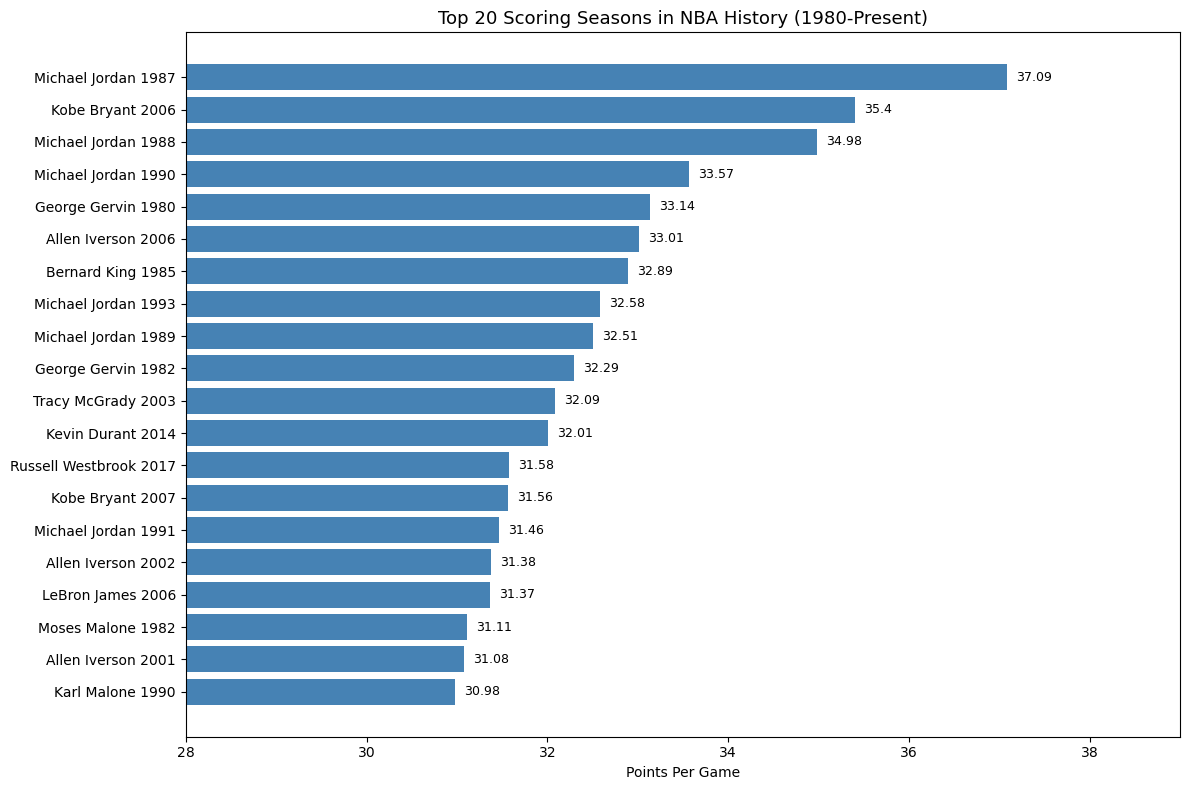

In [4]:
# Visualization: Top 20 scoring seasons as a horizontal bar chart
import matplotlib.pyplot as plt

# Create a clean label with player name and year
top_scorers['label'] = top_scorers['Player'].str.replace('*', '', regex=False) + ' ' + top_scorers['Year'].astype(int).astype(str)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_scorers['label'][::-1], top_scorers['points_per_game'][::-1], color='steelblue')

# Add value labels
for bar, val in zip(bars, top_scorers['points_per_game'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)

plt.xlabel('Points Per Game')
plt.title('Top 20 Scoring Seasons in NBA History (1980-Present)', fontsize=13)
plt.xlim(28, 39)
plt.tight_layout()
plt.show()

In [5]:
# Question 2: How has the NBA changed over time?
# Group by year to see league-wide trends in scoring, shooting, and 3-point attempts
query2 = """
SELECT 
    Year,
    ROUND(AVG(PPG), 2) as avg_points_per_game,
    ROUND(AVG("3PA"), 2) as avg_three_point_attempts,
    ROUND(AVG("FG%"), 3) as avg_fg_percentage,
    COUNT(DISTINCT Player) as total_players
FROM stats
WHERE G >= 20
GROUP BY Year
ORDER BY Year ASC
"""

trends = pd.read_sql(query2, conn)
print(trends.head(10))

     Year  avg_points_per_game  avg_three_point_attempts  avg_fg_percentage  \
0  1980.0                10.60                     17.98              0.469   
1  1981.0                10.00                     13.49              0.468   
2  1982.0                 9.95                     14.24              0.479   
3  1983.0                 9.79                     13.73              0.470   
4  1984.0                 9.95                     15.66              0.481   
5  1985.0                10.05                     19.90              0.480   
6  1986.0                 9.83                     21.06              0.474   
7  1987.0                 9.91                     29.36              0.466   
8  1988.0                 9.83                     30.94              0.470   
9  1989.0                 9.55                     38.96              0.460   

   total_players  
0            252  
1            270  
2            280  
3            280  
4            277  
5            282

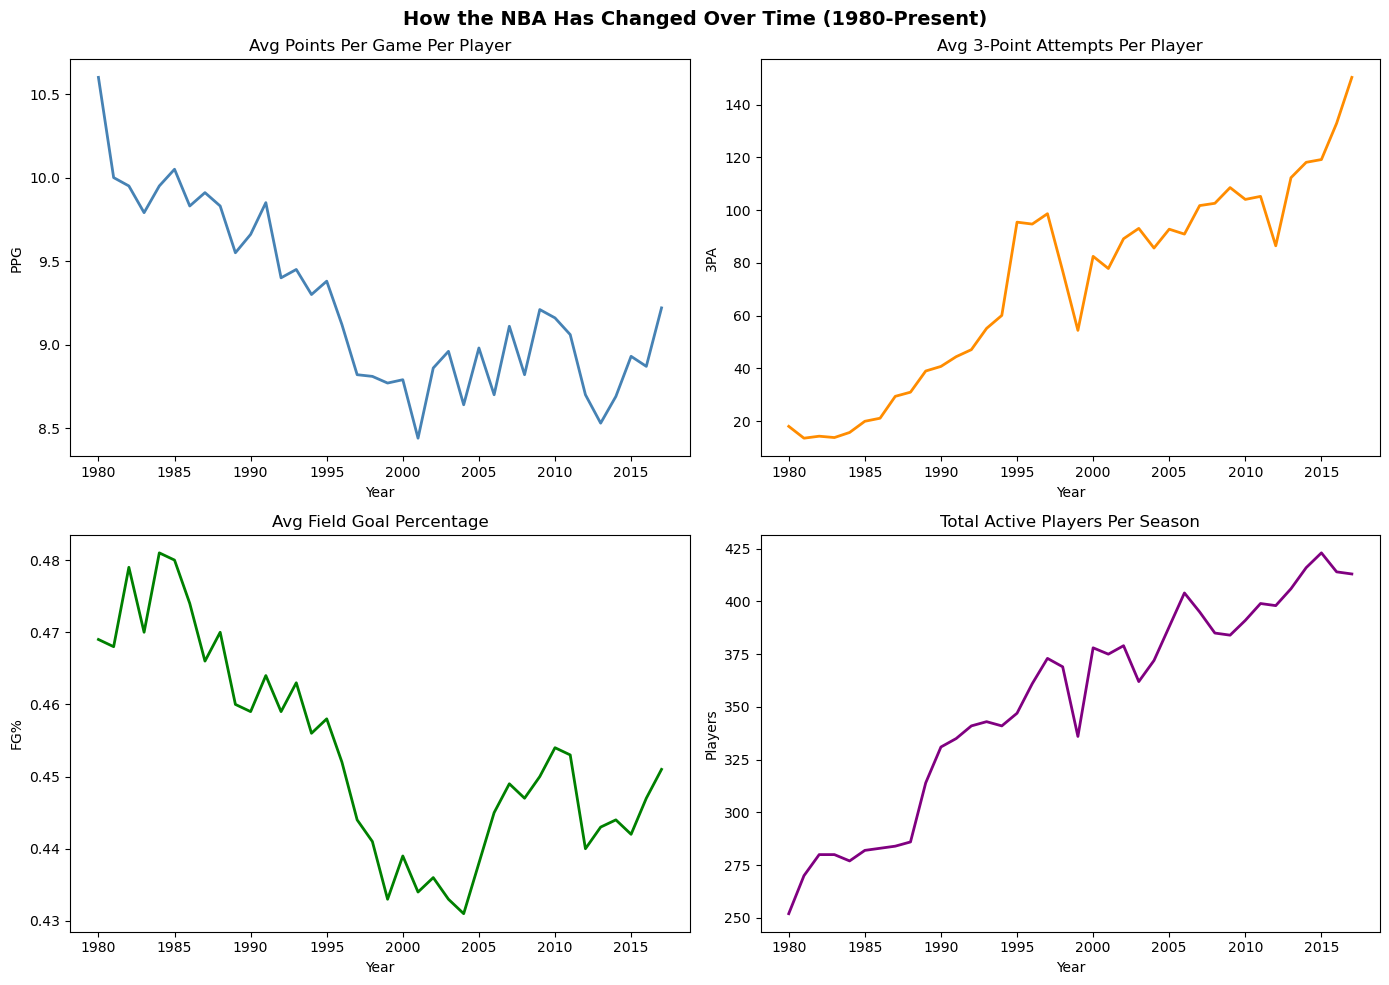

In [6]:
# Visualization: 4-panel chart showing PPG, 3PA, FG%, and total players over time
# Key finding: 3-point attempts increased 8x while FG% dropped - the modern NBA
# prioritizes volume 3-point shooting over efficiency because the math favors it
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('How the NBA Has Changed Over Time (1980-Present)', fontsize=14, fontweight='bold')

# Chart 1 - Average PPG over time
axes[0,0].plot(trends['Year'], trends['avg_points_per_game'], color='steelblue', linewidth=2)
axes[0,0].set_title('Avg Points Per Game Per Player')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('PPG')

# Chart 2 - 3 point attempts over time
axes[0,1].plot(trends['Year'], trends['avg_three_point_attempts'], color='darkorange', linewidth=2)
axes[0,1].set_title('Avg 3-Point Attempts Per Player')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('3PA')

# Chart 3 - FG% over time
axes[1,0].plot(trends['Year'], trends['avg_fg_percentage'], color='green', linewidth=2)
axes[1,0].set_title('Avg Field Goal Percentage')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('FG%')

# Chart 4 - Total players over time
axes[1,1].plot(trends['Year'], trends['total_players'], color='purple', linewidth=2)
axes[1,1].set_title('Total Active Players Per Season')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Players')

plt.tight_layout()
plt.show()

In [7]:
query3 = """
SELECT 
    Tm as team,
    COUNT(DISTINCT Player) as total_players,
    ROUND(AVG(PPG), 2) as avg_ppg,
    ROUND(AVG("FG%"), 3) as avg_fg_pct,
    ROUND(AVG(PPG * G), 1) as avg_total_points_contributed
FROM stats
WHERE G >= 41
    AND Year >= 2000
    AND Tm != 'TOT'
GROUP BY Tm
HAVING COUNT(DISTINCT Player) >= 20
ORDER BY avg_ppg DESC
LIMIT 15
"""

team_stats = pd.read_sql(query3, conn)
print(team_stats)

   team  total_players  avg_ppg  avg_fg_pct  avg_total_points_contributed
0   HOU             83    10.87       0.453                         749.5
1   OKC             34    10.80       0.465                         773.2
2   PHO             86    10.75       0.465                         754.0
3   SAC             82    10.67       0.454                         723.2
4   GSW             85    10.61       0.461                         735.1
5   DEN             81    10.55       0.456                         716.7
6   TOR             86    10.42       0.457                         725.2
7   NOP             27    10.38       0.458                         670.5
8   MEM             72    10.25       0.449                         710.2
9   LAL             85    10.21       0.445                         715.8
10  MIA             89    10.20       0.455                         692.9
11  LAC             86    10.20       0.457                         709.7
12  NYK             95    10.19       

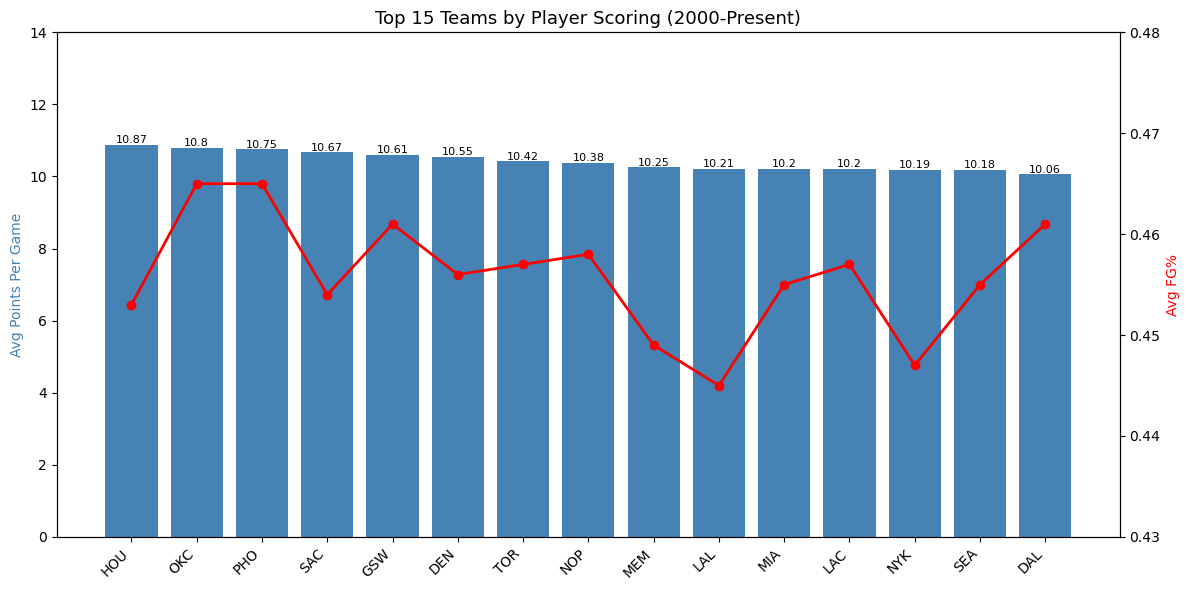

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(team_stats))
bars = ax1.bar(x, team_stats['avg_ppg'], color='steelblue')

ax2 = ax1.twinx()
ax2.plot(x, team_stats['avg_fg_pct'], color='red',
         linewidth=2, marker='o', markersize=6)

ax1.set_xticks(x)
ax1.set_xticklabels(team_stats['team'], rotation=45, ha='right')
ax1.set_ylabel('Avg Points Per Game', color='steelblue')
ax1.set_title('Top 15 Teams by Player Scoring (2000-Present)', fontsize=13)
ax2.set_ylabel('Avg FG%', color='red')

# Fix the axes ranges
ax1.set_ylim(0, 14)
ax2.set_ylim(0.43, 0.48)  # zoom into the FG% range so differences are visible

# Add value labels on bars
for i, v in enumerate(team_stats['avg_ppg']):
    ax1.text(i, v + 0.05, f'{v}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import sqlite3

# Reconnect to database
conn = sqlite3.connect('../data/nba.db')

# Recreate all three dataframes from the database
df_modern = pd.read_sql("SELECT * FROM stats", conn)

trends = pd.read_sql("""
    SELECT Year,
        ROUND(AVG(PPG), 2) as avg_points_per_game,
        ROUND(AVG("3PA"), 2) as avg_three_point_attempts,
        ROUND(AVG("FG%"), 3) as avg_fg_percentage,
        COUNT(DISTINCT Player) as total_players
    FROM stats
    WHERE G >= 20
    GROUP BY Year
    ORDER BY Year ASC
""", conn)

team_stats = pd.read_sql("""
    SELECT Tm as team,
        COUNT(DISTINCT Player) as total_players,
        ROUND(AVG(PPG), 2) as avg_ppg,
        ROUND(AVG("FG%"), 3) as avg_fg_pct
    FROM stats
    WHERE G >= 41 AND Year >= 2000 AND Tm != 'TOT'
    GROUP BY Tm
    HAVING COUNT(DISTINCT Player) >= 20
    ORDER BY avg_ppg DESC
    LIMIT 15
""", conn)

# Export all three to CSV
df_modern.to_csv('../data/nba_clean.csv', index=False)
trends.to_csv('../data/nba_trends.csv', index=False)
team_stats.to_csv('../data/nba_teams.csv', index=False)

print("Files exported!")

Files exported!
